In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f"Shape: {df.shape}")

Shape: (307511, 175)


In [13]:
# How much debt is the applicant taking relative to their income?
df['CREDIT_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

print(df['CREDIT_TO_INCOME_RATIO'].describe())

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_TO_INCOME_RATIO, dtype: float64


In [14]:
# How much debt is the applicant taking relative to their income?
df['CREDIT_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

print(df['CREDIT_TO_INCOME_RATIO'].describe())

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_TO_INCOME_RATIO, dtype: float64


In [15]:
# What % of monthly income goes toward loan repayment?
df['ANNUITY_TO_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

print(df['ANNUITY_TO_INCOME_RATIO'].describe())

count    307511.000000
mean          0.180929
std           0.094573
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_TO_INCOME_RATIO, dtype: float64


In [16]:
# How long is the loan? Longer loans = more exposure = more risk
df['CREDIT_TERM'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']

print(df['CREDIT_TERM'].describe())

count    307511.000000
mean         21.612366
std           7.824164
min           6.324539
25%          15.614473
50%          20.000000
75%          27.099985
max          59.560354
Name: CREDIT_TERM, dtype: float64


In [17]:
# Is the loan amount justified by the asset being purchased?
df['GOODS_TO_CREDIT_RATIO'] = df['AMT_GOODS_PRICE'] / df['AMT_CREDIT']

print(df['GOODS_TO_CREDIT_RATIO'].describe())

count    307511.000000
mean          0.901702
std           0.104845
min           0.166667
25%           0.834725
50%           0.893815
75%           1.000000
max           6.666667
Name: GOODS_TO_CREDIT_RATIO, dtype: float64


In [18]:
# How long has the applicant been employed relative to their age?
df['EMPLOYMENT_TO_AGE_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE_YEARS']

print(df['EMPLOYMENT_TO_AGE_RATIO'].describe())

count    307511.000000
mean          0.142371
std           0.124883
min           0.000000
25%           0.066852
50%           0.091037
75%           0.191054
max           0.728811
Name: EMPLOYMENT_TO_AGE_RATIO, dtype: float64


In [19]:
# How much income is available per dependent?
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

print(df['INCOME_PER_PERSON'].describe())

count    3.075110e+05
mean     9.310634e+04
std      1.013733e+05
min      2.812500e+03
25%      4.725000e+04
50%      7.500000e+04
75%      1.125000e+05
max      3.900000e+07
Name: INCOME_PER_PERSON, dtype: float64


Default rate by age band:
AGE_BAND
<25      0.123036
25-35    0.106733
35-45    0.084047
45-55    0.070580
55+      0.052155
Name: TARGET, dtype: float64


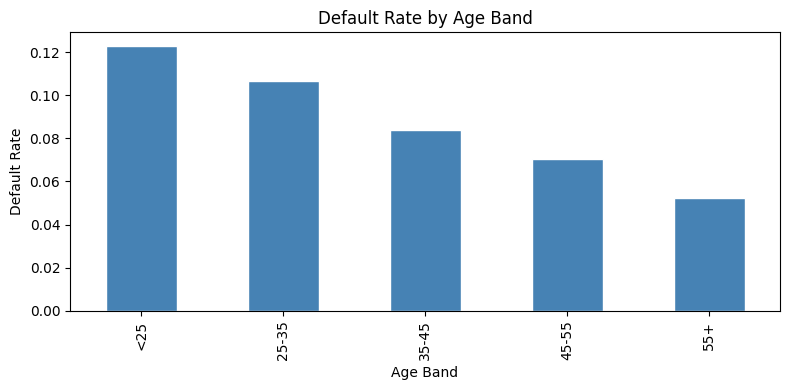

In [20]:
# Younger borrowers statistically default more — less financial stability
df['AGE_BAND'] = pd.cut(
    df['AGE_YEARS'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+']
)

# Default rate by age band
age_default = df.groupby('AGE_BAND', observed=True)['TARGET'].mean()
print("Default rate by age band:")
print(age_default)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
age_default.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Default Rate by Age Band')
ax.set_ylabel('Default Rate')
ax.set_xlabel('Age Band')
plt.tight_layout()
plt.show()

# Drop the band column after analysis — keep AGE_YEARS for modeling
df.drop(columns=['AGE_BAND'], inplace=True)

In [21]:
# Check if EXT_SOURCE columns exist
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
for col in ext_cols:
    print(f"{col}: {'EXISTS' if col in df.columns else 'MISSING'}")

EXT_SOURCE_1: EXISTS
EXT_SOURCE_2: EXISTS
EXT_SOURCE_3: EXISTS


In [22]:
# EXT_SOURCE_1/2/3 are credit bureau scores — very powerful features
# Create aggregate features from them

ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)
df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)
df['EXT_SOURCE_MAX']  = df[ext_cols].max(axis=1)
df['EXT_SOURCE_STD']  = df[ext_cols].std(axis=1)

print(df[['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 
          'EXT_SOURCE_MAX', 'EXT_SOURCE_STD']].describe())

       EXT_SOURCE_MEAN  EXT_SOURCE_MIN  EXT_SOURCE_MAX  EXT_SOURCE_STD
count    307511.000000    3.075110e+05   307511.000000   307511.000000
mean          0.511503    3.720009e-01        0.642007        0.141598
std           0.108104    1.551778e-01        0.109909        0.075224
min           0.023705    8.173617e-08        0.032977        0.000261
25%           0.441604    2.539628e-01        0.540662        0.085834
50%           0.521564    4.034627e-01        0.648336        0.130825
75%           0.587715    5.059979e-01        0.725276        0.189184
max           0.853417    8.068084e-01        0.962693        0.486962


In [23]:
# Check new features
new_features = [
    'CREDIT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO', 'CREDIT_TERM',
    'GOODS_TO_CREDIT_RATIO', 'EMPLOYMENT_TO_AGE_RATIO', 'INCOME_PER_PERSON',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_STD'
]

print("New features summary:")
print(df[new_features].describe().T[['mean', 'std', 'min', 'max']])

# Check for any infinities created by division
inf_check = df[new_features].replace([np.inf, -np.inf], np.nan).isnull().sum()
print("\nInfinity/NaN check:")
print(inf_check)

# Replace any inf values
df[new_features] = df[new_features].replace([np.inf, -np.inf], np.nan)
df[new_features] = df[new_features].fillna(df[new_features].median())

# Save
df.to_csv('../data/processed/featured_data.csv', index=False)
print(f"\nSaved. Final shape: {df.shape}")

New features summary:
                                 mean            std           min  \
CREDIT_TO_INCOME_RATIO       3.957570       2.689728  4.807615e-03   
ANNUITY_TO_INCOME_RATIO      0.180929       0.094573  2.238846e-04   
CREDIT_TERM                 21.612366       7.824164  6.324539e+00   
GOODS_TO_CREDIT_RATIO        0.901702       0.104845  1.666667e-01   
EMPLOYMENT_TO_AGE_RATIO      0.142371       0.124883  0.000000e+00   
INCOME_PER_PERSON        93106.335038  101373.313820  2.812500e+03   
EXT_SOURCE_MEAN              0.511503       0.108104  2.370490e-02   
EXT_SOURCE_MIN               0.372001       0.155178  8.173617e-08   
EXT_SOURCE_MAX               0.642007       0.109909  3.297727e-02   
EXT_SOURCE_STD               0.141598       0.075224  2.613142e-04   

                                  max  
CREDIT_TO_INCOME_RATIO   8.473684e+01  
ANNUITY_TO_INCOME_RATIO  1.875965e+00  
CREDIT_TERM              5.956035e+01  
GOODS_TO_CREDIT_RATIO    6.666667e+00  
EMPLOYM